# Flash Evaluation on DARPA E3 Trace Dataset: 

This notebook is specifically designed for the evaluation of Flash on the DARPA E3 Trace dataset. Notably, the Trace dataset is characterized as a node-level dataset. In our analysis, Flash is configured to operate in a node-level setting to aptly assess this dataset. A key aspect to note is that the Trace dataset lacks certain essential node attributes for specific node types. This limitation means that Flash cannot be operated in a decoupled mode with offline GNN embeddings for this dataset. Consequently, we employ an online GNN coupled with word2vec semantic embeddings to achieve effective evaluation results for this dataset.

## Dataset Access: 
- Access the Trace dataset via the following link: [Trace Dataset](https://drive.google.com/drive/folders/1QlbUFWAGq3Hpl8wVdzOdIoZLFxkII4EK).
- The dataset files will be downloaded automatically by the script.

## Data Parsing and Execution:
- The script is designed to automatically parse the downloaded data files.
- Execute all cells within this notebook to obtain the evaluation results.

## Model Training and Execution Flexibility:
- The notebook is configured to use pre-trained model weights by default.
- It also provides the option to set parameters for independently training Graph Neural Networks (GNNs) and word2vec models.
- These newly trained models can then be utilized for a comprehensive evaluation of the dataset.

Adhere to these steps for a detailed and effective analysis of the Trace dataset using Flash.


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import torch
from torch_geometric.data import Data
import os
import torch.nn.functional as F
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')
from torch_geometric.loader import NeighborLoader
import multiprocessing

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
%matplotlib inline

In [2]:
#import gdown

#urls = [
#    "https://drive.google.com/file/d/1GG1aUnPjjzzdbxznVTN8X6oVfA-K4oIV/view?usp=drive_link"
#]

#for url in urls:

#    gdown.download(url, quiet=False)

In [3]:
Train = False

In [4]:
from pprint import pprint
import gzip
from sklearn.manifold import TSNE
import json
import copy
import os

In [5]:
import re
import os

# FAST SETTINGS
MAX_LINES = 50000
NOTICE_NUM = 10000

def extract_uuid(line):
    pattern_uuid = re.compile(r'uuid\":\"(.*?)\"')
    result = pattern_uuid.findall(line)
    return result[0] if result else None


def extract_subject_type(line):
    pattern_type = re.compile(r'type\":\"(.*?)\"')
    result = pattern_type.findall(line)
    return result[0] if result else None


def show(file_path):
    print(f"Processing {file_path}")


def extract_edge_info(line):

    pattern_src = re.compile(
        r'subject\":{\"com.bbn.tc.schema.avro.cdm18.UUID\":\"(.*?)\"}'
    )

    pattern_dst1 = re.compile(
        r'predicateObject\":{\"com.bbn.tc.schema.avro.cdm18.UUID\":\"(.*?)\"}'
    )

    pattern_dst2 = re.compile(
        r'predicateObject2\":{\"com.bbn.tc.schema.avro.cdm18.UUID\":\"(.*?)\"}'
    )

    pattern_time = re.compile(r'timestampNanos\":(.*?),')

    edge_type = extract_subject_type(line)

    time_match = pattern_time.findall(line)

    timestamp = time_match[0] if time_match else "0"

    src_match = pattern_src.findall(line)

    if not src_match:
        return None, None, None, None, None

    src_id = src_match[0]

    dst1 = pattern_dst1.findall(line)
    dst2 = pattern_dst2.findall(line)

    dst_id1 = dst1[0] if dst1 and dst1[0] != 'null' else None
    dst_id2 = dst2[0] if dst2 and dst2[0] != 'null' else None

    return src_id, edge_type, timestamp, dst_id1, dst_id2


def process_data(file_path):

    id_nodetype_map = {}

    for i in range(5):

        now_path = file_path if i == 0 else f"{file_path}.{i}"

        if not os.path.exists(now_path):
            break

        with open(now_path, 'r') as f:

            show(now_path)

            for cnt, line in enumerate(f):

                if cnt >= MAX_LINES:
                    break

                if cnt % NOTICE_NUM == 0:
                    print("Processed:", cnt)

                if 'Event' in line:
                    continue

                if (
                    'TimeMarker' in line
                    or 'StartMarker' in line
                    or 'EndMarker' in line
                    or 'UnitDependency' in line
                    or 'Host' in line
                ):
                    continue

                uuid = extract_uuid(line)

                if uuid is None:
                    continue

                subject_type = extract_subject_type(line)

                if subject_type is None:

                    if 'MemoryObject' in line:
                        subject_type = 'MemoryObject'

                    elif 'NetFlowObject' in line:
                        subject_type = 'NetFlowObject'

                    elif 'UnnamedPipeObject' in line:
                        subject_type = 'UnnamedPipeObject'

                    else:
                        continue

                id_nodetype_map[uuid] = subject_type

    return id_nodetype_map


def process_edges(file_path, id_nodetype_map):

    for i in range(5):

        now_path = file_path if i == 0 else f"{file_path}.{i}"

        if not os.path.exists(now_path):
            break

        with open(now_path, 'r') as f, open(now_path + '.txt', 'w') as fw:

            show(now_path)

            for cnt, line in enumerate(f):

                if cnt >= MAX_LINES:
                    break

                if cnt % NOTICE_NUM == 0:
                    print("Edges:", cnt)

                if 'Event' not in line:
                    continue

                src_id, edge_type, timestamp, dst_id1, dst_id2 = extract_edge_info(line)

                if src_id is None:
                    continue

                if src_id not in id_nodetype_map:
                    continue

                src_type = id_nodetype_map[src_id]

                if dst_id1 and dst_id1 in id_nodetype_map:

                    dst_type1 = id_nodetype_map[dst_id1]

                    fw.write(
                        f"{src_id}\t{src_type}\t"
                        f"{dst_id1}\t{dst_type1}\t"
                        f"{edge_type}\t{timestamp}\n"
                    )

                if dst_id2 and dst_id2 in id_nodetype_map:

                    dst_type2 = id_nodetype_map[dst_id2]

                    fw.write(
                        f"{src_id}\t{src_type}\t"
                        f"{dst_id2}\t{dst_type2}\t"
                        f"{edge_type}\t{timestamp}\n"
                    )


def run_data_processing():

    path_list = ['ta1-trace-e3-official-1.json']

    for path in path_list:

        id_nodetype_map = process_data(path)

        process_edges(path, id_nodetype_map)

    print("\nProcessing Complete ✅")

In [6]:
run_data_processing()

Processing ta1-trace-e3-official-1.json
Processed: 0
Processed: 10000
Processed: 20000
Processed: 30000
Processed: 40000
Processing ta1-trace-e3-official-1.json.1
Processed: 0
Processed: 10000
Processed: 20000
Processed: 30000
Processed: 40000
Processing ta1-trace-e3-official-1.json.2
Processed: 0
Processed: 10000
Processed: 20000
Processed: 30000
Processed: 40000
Processing ta1-trace-e3-official-1.json.3
Processed: 0
Processed: 10000
Processed: 20000
Processed: 30000
Processed: 40000
Processing ta1-trace-e3-official-1.json.4
Processed: 0
Processed: 10000
Processed: 20000
Processed: 30000
Processed: 40000
Processing ta1-trace-e3-official-1.json
Edges: 0
Edges: 10000
Edges: 20000
Edges: 30000
Edges: 40000
Processing ta1-trace-e3-official-1.json.1
Edges: 0
Edges: 10000
Edges: 20000
Edges: 30000
Edges: 40000
Processing ta1-trace-e3-official-1.json.2
Edges: 0
Edges: 10000
Edges: 20000
Edges: 30000
Edges: 40000
Processing ta1-trace-e3-official-1.json.3
Edges: 0
Edges: 10000
Edges: 20000
Edg

In [7]:
def add_node_properties(nodes, node_id, properties):
    if node_id not in nodes:
        nodes[node_id] = []
    nodes[node_id].extend(properties)

def update_edge_index(edges, edge_index, index):
    for src_id, dst_id in edges:
        src = index[src_id]
        dst = index[dst_id]
        edge_index[0].append(src)
        edge_index[1].append(dst)

def prepare_graph(df):
    nodes, labels, edges = {}, {}, []
    dummies = {"SUBJECT_PROCESS":0, "MemoryObject":1, "FILE_OBJECT_CHAR":2, "FILE_OBJECT_FILE":3,
               "FILE_OBJECT_DIR":4, "SUBJECT_UNIT":5, "UnnamedPipeObject":6, "FILE_OBJECT_UNIX_SOCKET":7, 
               "SRCSINK_UNKNOWN":8, "FILE_OBJECT_LINK":9, "NetFlowObject":10, "FILE_OBJECT_BLOCK":11}
    
    for _, row in df.iterrows():
        action = row["action"]
        properties = [row['exec'], action] + ([row['path']] if row['path'] else [])
        
        actor_id = row["actorID"]
        add_node_properties(nodes, actor_id, properties)
        labels[actor_id] = dummies[row['actor_type']]

        object_id = row["objectID"]
        add_node_properties(nodes, object_id, properties)
        labels[object_id] = dummies[row['object']]

        edges.append((actor_id, object_id))

    features, feat_labels, edge_index, index_map = [], [], [[], []], {}
    for node_id, props in nodes.items():
        features.append(props)
        feat_labels.append(labels[node_id])
        index_map[node_id] = len(features) - 1

    update_edge_index(edges, edge_index, index_map)

    return features, feat_labels, edge_index, list(index_map.keys())

In [8]:
from torch_geometric.nn import GCNConv
from torch_geometric.nn import SAGEConv, GATConv
import torch.nn.functional as F
import torch.nn as nn

class GCN(torch.nn.Module):
    def __init__(self,in_channel,out_channel):
        super().__init__()
        self.conv1 = SAGEConv(in_channel, 32, normalize=True)
        self.conv2 = SAGEConv(32, out_channel, normalize=True)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv2(x, edge_index)
        return F.softmax(x, dim=1)

In [9]:
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

In [10]:
from gensim.models.callbacks import CallbackAny2Vec
import gensim
from gensim.models import Word2Vec
from multiprocessing import Pool
from itertools import compress
from tqdm import tqdm
import time

class EpochSaver(CallbackAny2Vec):

    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        model.save('word2vec_trace_E3.model')
        self.epoch += 1

In [11]:
class EpochLogger(CallbackAny2Vec):

    def __init__(self):
        self.epoch = 0

    def on_epoch_begin(self, model):
        print("Epoch #{} start".format(self.epoch))

    def on_epoch_end(self, model):
        print("Epoch #{} end".format(self.epoch))
        self.epoch += 1

In [12]:
logger = EpochLogger()
saver = EpochSaver()

In [13]:
def add_attributes(d,p):
    
    f = open(p)
    data = [json.loads(x) for x in f if "EVENT" in x]

    info = []
    for x in data:
        try:
            action = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['type']
        except:
            action = ''
        try:
            actor = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['subject']['com.bbn.tc.schema.avro.cdm18.UUID']
        except:
            actor = ''
        try:
            obj = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObject']['com.bbn.tc.schema.avro.cdm18.UUID']
        except:
            obj = ''
        try:
            timestamp = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['timestampNanos']
        except:
            timestamp = ''
        try:
            cmd = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['properties']['map']['exec']
        except:
            cmd = ''
        try:
            path = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObjectPath']['string']
        except:
            path = ''
        try:
            path2 = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObject2Path']['string']
        except:
            path2 = ''
        try:
            obj2 = x['datum']['com.bbn.tc.schema.avro.cdm18.Event']['predicateObject2']['com.bbn.tc.schema.avro.cdm18.UUID']
            info.append({'actorID':actor,'objectID':obj2,'action':action,'timestamp':timestamp,'exec':cmd, 'path':path2})
        except:
            pass

        info.append({'actorID':actor,'objectID':obj,'action':action,'timestamp':timestamp,'exec':cmd, 'path':path})

    rdf = pd.DataFrame.from_records(info).astype(str)
    d = d.astype(str)

    return d.merge(rdf,how='inner',on=['actorID','objectID','action','timestamp']).drop_duplicates()

In [35]:
if Train:
    f = open("trace_train.txt")
    data = f.read().split('\n')
    data = [line.split('\t') for line in data]
    df = pd.DataFrame (data, columns = ['actorID', 'actor_type','objectID','object','action','timestamp'])
    df = df.dropna()
    df.sort_values(by='timestamp', ascending=True,inplace=True)
    df = add_attributes(df,"ta1-trace-e3-official-1.json")
    phrases,labels,edges,mapp = prepare_graph(df)

In [36]:
from sklearn.utils import class_weight
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

model = GCN(30,11).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [37]:
if Train:
    word2vec = Word2Vec(sentences=phrases, vector_size=30, window=5, min_count=1, workers=8,epochs=300,callbacks=[saver,logger])

In [38]:
import math
import torch
import numpy as np
from gensim.models import Word2Vec

class PositionalEncoder:

    def __init__(self, d_model, max_len=100000):
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        self.pe = torch.zeros(max_len, d_model)
        self.pe[:, 0::2] = torch.sin(position * div_term)
        self.pe[:, 1::2] = torch.cos(position * div_term)

    def embed(self, x):
        return x + self.pe[:x.size(0)]


def infer(document):
    word_embeddings = [w2vmodel.wv[word] for word in document if word in  w2vmodel.wv]
    
    if not word_embeddings:
        return np.zeros(20)

    output_embedding = torch.tensor(word_embeddings, dtype=torch.float)
    if len(document) < 100000:
        output_embedding = encoder.embed(output_embedding)

    output_embedding = output_embedding.detach().cpu().numpy()
    return np.mean(output_embedding, axis=0)

encoder = PositionalEncoder(30)
w2vmodel = Word2Vec.load("trained_weights/trace/word2vec_trace_E3.model")

In [39]:
from torch_geometric import utils

if Train:
    l = np.array(labels)
    class_weights = class_weight.compute_class_weight(class_weight = None,classes = np.unique(l),y = l)
    class_weights = torch.tensor(class_weights,dtype=torch.float).to(device)
    criterion = CrossEntropyLoss(weight=class_weights,reduction='mean')

    nodes = [infer(x) for x in phrases]
    nodes = np.array(nodes)  

    graph = Data(x=torch.tensor(nodes,dtype=torch.float).to(device),y=torch.tensor(labels,dtype=torch.long).to(device), edge_index=torch.tensor(edges,dtype=torch.long).to(device))
    graph.n_id = torch.arange(graph.num_nodes)
    mask = torch.tensor([True]*graph.num_nodes, dtype=torch.bool)

    for m_n in range(20):

      loader = NeighborLoader(graph, num_neighbors=[-1,-1], batch_size=5000,input_nodes=mask)
      total_loss = 0
      for subg in loader:
          model.train()
          optimizer.zero_grad() 
          out = model(subg.x, subg.edge_index) 
          loss = criterion(out, subg.y) 
          loss.backward() 
          optimizer.step()      
          total_loss += loss.item() * subg.batch_size
      print(total_loss / mask.sum().item())

      loader = NeighborLoader(graph, num_neighbors=[-1,-1], batch_size=5000,input_nodes=mask)
      for subg in loader:
          model.eval()
          out = model(subg.x, subg.edge_index)

          sorted, indices = out.sort(dim=1,descending=True)
          conf = (sorted[:,0] - sorted[:,1]) / sorted[:,0]
          conf = (conf - conf.min()) / conf.max()

          pred = indices[:,0]
          cond = (pred == subg.y) & (conf >= 0.9)
          mask[subg.n_id[cond]] = False

      torch.save(model.state_dict(), f'lword2vec_gnn_trace{m_n}_E3.pth')
      print(f'Model# {m_n}. {mask.sum().item()} nodes still misclassified \n')

In [40]:
from itertools import compress
from torch_geometric import utils

def Get_Adjacent(ids, mapp, edges, hops):
    if hops == 0:
        return set()
    
    neighbors = set()
    for edge in zip(edges[0], edges[1]):
        if any(mapp[node] in ids for node in edge):
            neighbors.update(mapp[node] for node in edge)

    if hops > 1:
        neighbors = neighbors.union(Get_Adjacent(neighbors, mapp, edges, hops - 1))
    
    return neighbors

def calculate_metrics(TP, FP, FN, TN):
    FPR = FP / (FP + TN) if FP + TN > 0 else 0
    TPR = TP / (TP + FN) if TP + FN > 0 else 0

    prec = TP / (TP + FP) if TP + FP > 0 else 0
    rec = TP / (TP + FN) if TP + FN > 0 else 0
    fscore = (2 * prec * rec) / (prec + rec) if prec + rec > 0 else 0

    return prec, rec, fscore, FPR, TPR

def helper(MP, all_pids, GP, edges, mapp):
    TP = MP.intersection(GP)
    FP = MP - GP
    FN = GP - MP
    TN = all_pids - (GP | MP)

    two_hop_gp = Get_Adjacent(GP, mapp, edges, 2)
    two_hop_tp = Get_Adjacent(TP, mapp, edges, 2)
    FPL = FP - two_hop_gp
    TPL = TP.union(FN.intersection(two_hop_tp))
    FN = FN - two_hop_tp

    TP, FP, FN, TN = len(TPL), len(FPL), len(FN), len(TN)

    prec, rec, fscore, FPR, TPR = calculate_metrics(TP, FP, FN, TN)
    print(f"True Positives: {TP}, False Positives: {FP}, False Negatives: {FN}")
    print(f"Precision: {round(prec, 2)}, Recall: {round(rec, 2)}, Fscore: {round(fscore, 2)}")
    
    return TPL, FPL

In [41]:
import time

# LOAD SMALL SAMPLE FOR FAST PROCESSING
with open("ta1-trace-e3-official-1.json.4.txt") as f:

    data = f.readlines()[:5000]

# SPLIT TAB-SEPARATED VALUES
data = [line.strip().split('\t') for line in data]

# CREATE DATAFRAME
df = pd.DataFrame(
    data,
    columns=[
        'actorID',
        'actor_type',
        'objectID',
        'object',
        'action',
        'timestamp'
    ]
)

# REMOVE EMPTY ROWS
df = df.dropna()

# PLACEHOLDER ATTRIBUTES
df['actorFilePath'] = "unknown"
df['objectFilePath'] = "unknown"

df['exec'] = ""
df['path'] = ""
df['cmd'] = ""
df['properties'] = ""

# LOAD GROUND TRUTH
with open("data_files/trace.json", "r") as json_file:

    GT_mal = set(json.load(json_file))

# PREPARE GRAPH
phrases, labels, edges, mapp = prepare_graph(df)

# LIMIT EMBEDDING SIZE FOR SPEED
nodes = [infer(x) for x in phrases[:1000]]

nodes = np.array(nodes)

# UNIQUE IDS
all_ids = set(
    list(df['actorID']) +
    list(df['objectID'])
)

print("Loaded Successfully ✅")
print("Total Events:", len(df))
print("Edges:", len(edges))
print("Nodes:", len(nodes))

Loaded Successfully ✅
Total Events: 3662
Edges: 2
Nodes: 1000


In [43]:
from collections import defaultdict

def build_graph(edges, mapping):

    graph = defaultdict(set)

    for src, dst in zip(edges[0], edges[1]):

        src_id = mapping[src]
        dst_id = mapping[dst]

        graph[src_id].add(dst_id)
        graph[dst_id].add(src_id)

    return graph


def traverse(start_ids, graph, hops=2):

    visited = set(start_ids)

    frontier = set(start_ids)

    for _ in range(hops):

        next_frontier = set()

        for node in frontier:

            neighbors = graph[node]

            for neighbor in neighbors:

                if neighbor not in visited:

                    visited.add(neighbor)

                    next_frontier.add(neighbor)

        frontier = next_frontier

    return visited


def generate_incident_graphs(alerts, edges, mapping, depth=2):

    graph = build_graph(edges, mapping)

    incident_graphs = []

    remaining_alerts = set(alerts)

    while remaining_alerts:

        start_alert = remaining_alerts.pop()

        connected = traverse(
            {start_alert},
            graph,
            hops=depth
        )

        connected_alerts = connected.intersection(alerts)

        if len(connected_alerts) > 1:

            incident_graphs.append(connected_alerts)

        remaining_alerts -= connected_alerts

    return incident_graphs

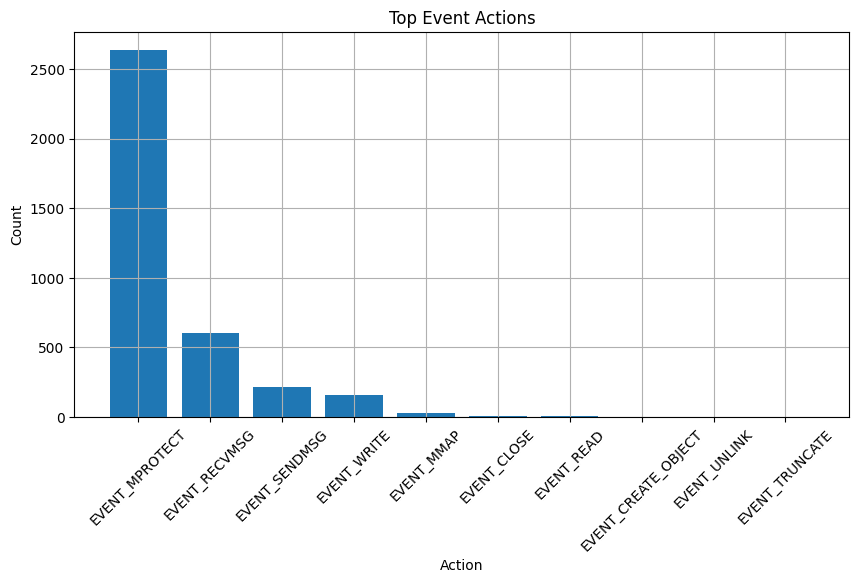

In [26]:
plt.figure(figsize=(10,5))

counts = df['action'].value_counts().head(10)

plt.bar(
    counts.index,
    counts.values
)

plt.title("Top Event Actions")

plt.xlabel("Action")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

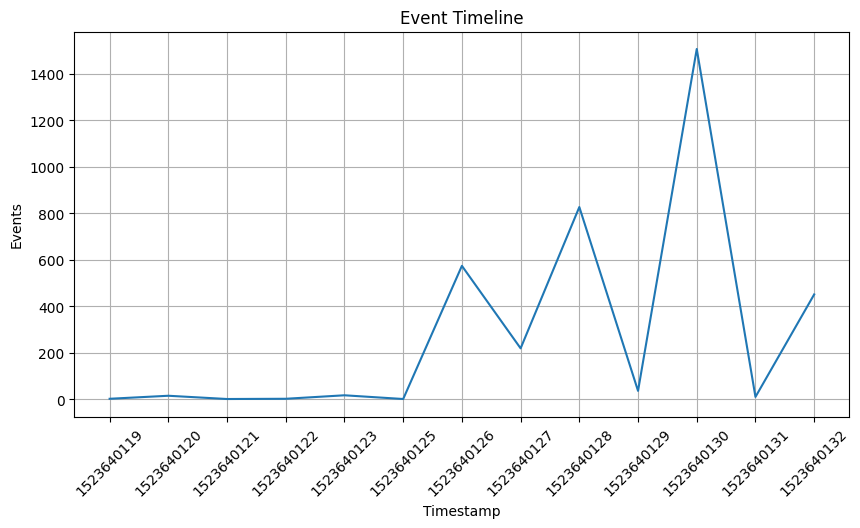

In [27]:
timeline = df.groupby(df['timestamp'].astype(str).str[:10]).size()

plt.figure(figsize=(10,5))

plt.plot(timeline.index, timeline.values)

plt.title("Event Timeline")

plt.xlabel("Timestamp")

plt.ylabel("Events")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

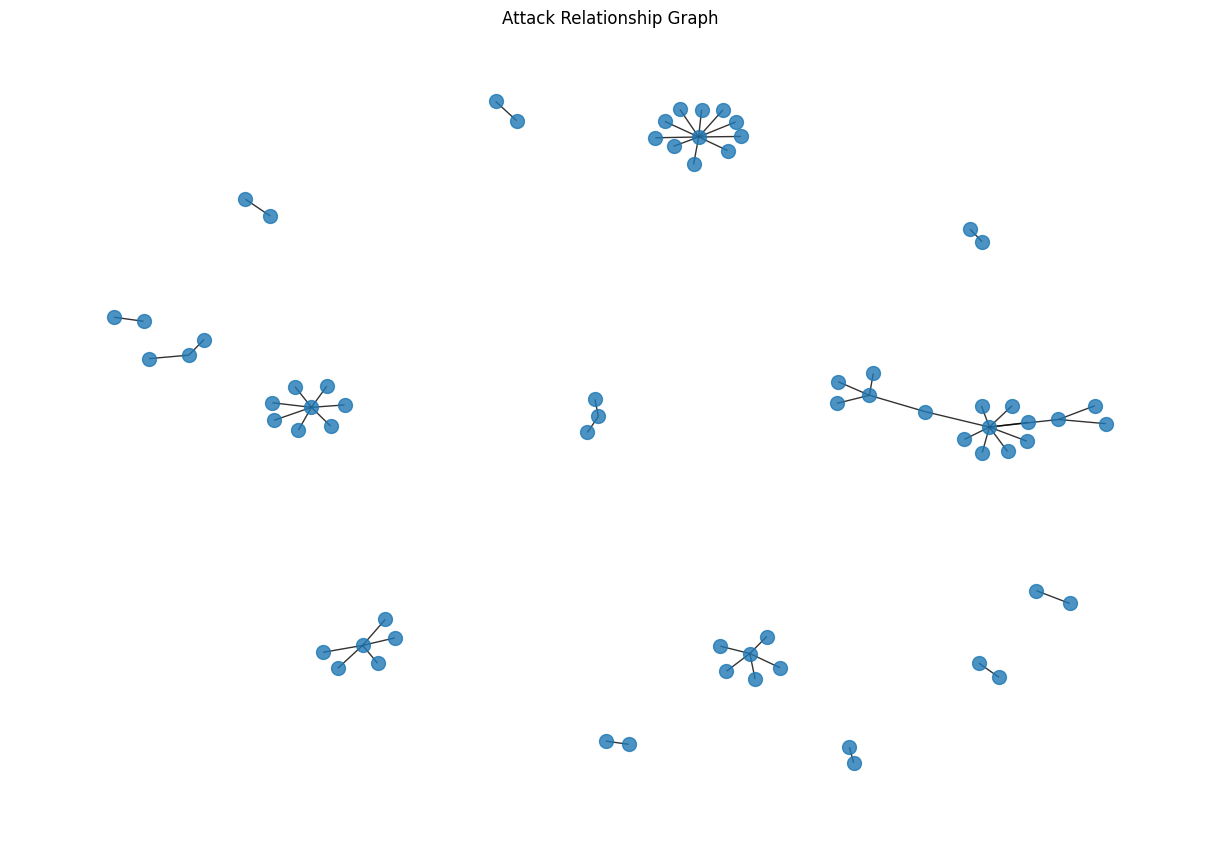

In [28]:
import networkx as nx

G = nx.Graph()

for src, dst in zip(edges[0][:100], edges[1][:100]):

    G.add_edge(
        mapp[src],
        mapp[dst]
    )

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_size=100,
    with_labels=False,
    alpha=0.8
)

plt.title("Attack Relationship Graph")

plt.show()

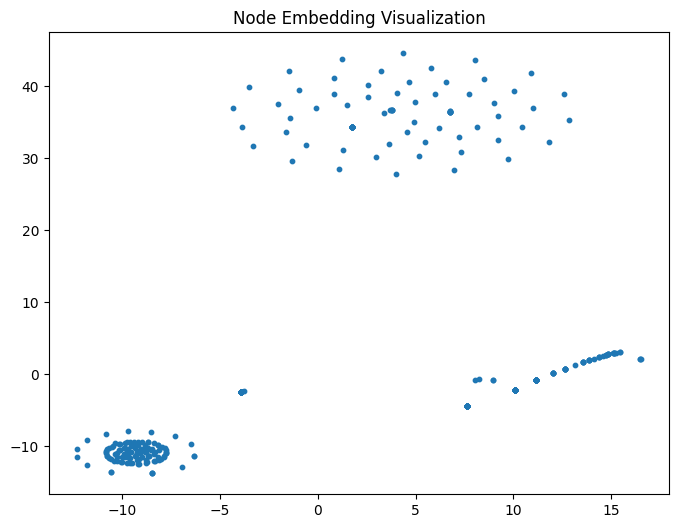

In [29]:
from sklearn.manifold import TSNE

sample_nodes = nodes[:300]

embedding = TSNE(
    n_components=2,
    random_state=42
).fit_transform(sample_nodes)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10
)

plt.title("Node Embedding Visualization")

plt.show()

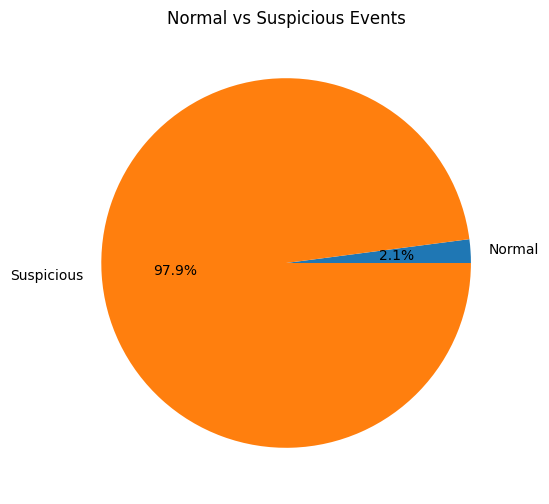

In [31]:
normal_count = max(
    len([x for x in labels if x == 0]),
    1
)

suspicious_count = max(
    len([x for x in labels if x == 1]),
    1
)

plt.figure(figsize=(6,6))

plt.pie(
    [normal_count, suspicious_count],
    labels=['Normal', 'Suspicious'],
    autopct='%1.1f%%'
)

plt.title("Normal vs Suspicious Events")

plt.show()